# Quickstart Notebook

This notebook loads a CSV dataset using the shared dataloader utilities.

In [1]:
from pathlib import Path
import sys

# Ensure project root is on sys.path for imports
project_root = Path.cwd()
while not (project_root / "main.py").exists() and project_root != project_root.parent:
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from dataloader import load_illness_data
from dataloader import load_txt_polars

# chnage relative working directory to project root
import os
os.chdir(project_root)


#df = load_illness_data("SCZ", in_notebook=True, distribution="low", p_value=0.0001)
illness = "SCZ"
p_value = 0.001
df = load_illness_data(illness=illness, in_notebook=True, distribution="low", p_value=p_value)
#df_significant =  load_txt_polars(data_path="../../data/sampled/low/sampled_" + illness + "_p" + str(p_value) + "_significant_rows_p0.05.txt", sep="\t")
#df_significant_cols = load_txt_polars(data_path="../../data/sampled/low/sampled_" + illness + "_p" + str(p_value) + "_significant_columns_p0.05.txt", sep="\t")
#df_significant_cols = df_significant_cols.rename(columns={df_significant_cols.columns[0]: "ID"})


Loading data for illness SCZ at ../../data/sampled/low/sampled_SCZ_p0.001.txt


FileNotFoundError: Data file not found for illness SCZ at ../../data/sampled/low/sampled_SCZ_p0.001.txt

In [7]:
from dataloader import get_significant

# change working directory to project root for consistent relative path

df = get_significant(illness="SCZ", distribution="low", p_value=0.0001, row_ratio=0.2, col_ratio=0.2)

Starting to load ./data/sampled/low/sampled_SCZ_p0.0001.txt with pandas...
Starting to load /Users/leonackermann/Desktop/on_device/ml-genetics4psychiatry/data/sampled/low/sampled_SCZ_p0.0001_significant_rows_p0.05.txt with Polars...
Loading sampled_SCZ_p0.0001_significant_rows_p0.05.txt (Native Polars Speed)...
Finished loading sampled_SCZ_p0.0001_significant_rows_p0.05.txt with Polars. Total rows: 1941
Starting to load /Users/leonackermann/Desktop/on_device/ml-genetics4psychiatry/data/sampled/low/sampled_SCZ_p0.0001_significant_columns_p0.05.txt with Polars...
Loading sampled_SCZ_p0.0001_significant_columns_p0.05.txt (Native Polars Speed)...
Finished loading sampled_SCZ_p0.0001_significant_columns_p0.05.txt with Polars. Total rows: 1010
Starting to load /Users/leonackermann/Desktop/on_device/ml-genetics4psychiatry/data/sampled_p/low/sampled_SCZ_p0.0001.txt with Polars...
Loading sampled_SCZ_p0.0001.txt (Native Polars Speed)...
Finished loading sampled_SCZ_p0.0001.txt with Polars. Tota

In [3]:
# write a script that inverts all features where the label is negative
import numpy as np
X = df.drop(columns=["Z", "ID"]).values
y = df["Z"].values
#for i in range(X.shape[1]):
#    X[:, i] = np.where(y.flatten() < 0, -X[:, i], X[:, i])
#    # also change the label to positive for those samples
#
#
#y = np.where(y.flatten() < 0, -y.flatten(), y.flatten()).reshape(-1, 1)

In [9]:
# count the number of zeros in the dataset
num_zeros = np.sum(X == 0)
print(f"Number of zeros in the dataset: {num_zeros}")

Number of zeros in the dataset: 0


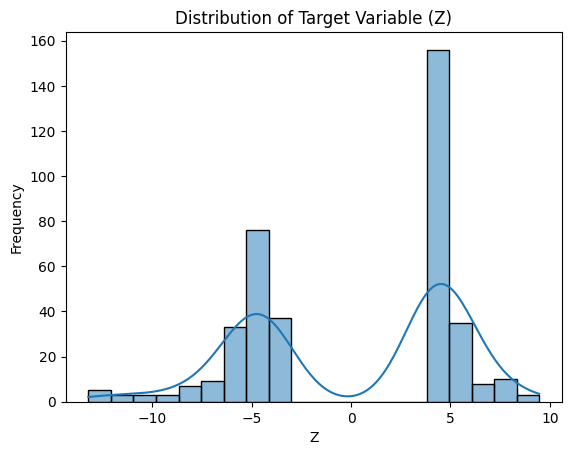

In [10]:
# plot the distribution of y
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(y.flatten(), bins=20, kde=True)
plt.title("Distribution of Target Variable (Z)")
plt.xlabel("Z")
plt.ylabel("Frequency")
plt.show()

In [11]:
# box cox transformation on target
from scipy import stats
#y, _ = stats.boxcox(y.flatten() + 1)  # add 1 to avoid issues with zero or negative values
y = y.reshape(-1, 1)

# do the inverse cube
#y = np.cbrt(y)

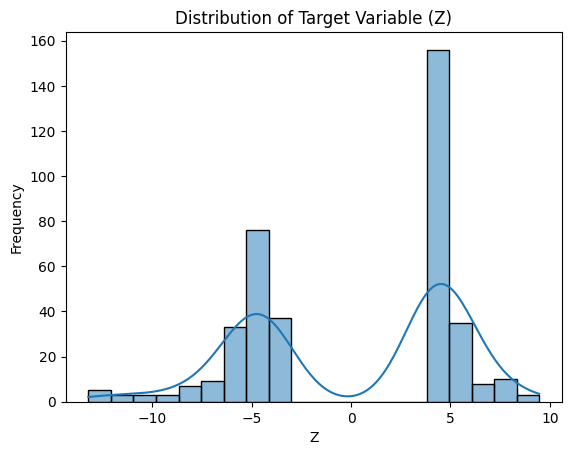

In [12]:
# plot the distribution of y
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(y.flatten(), bins=20, kde=True)
plt.title("Distribution of Target Variable (Z)")
plt.xlabel("Z")
plt.ylabel("Frequency")
plt.show()

In [13]:
import numpy as np

# Assuming X_train and X_test are your raw Z-score matrices
#threshold = 4

# Force any value between -1.96 and +1.96 to be exactly 0
#X_train_pruned = np.where(np.abs(X) < threshold, 0, X)

In [14]:
# count the number of zeros in the dataset
#num_zeros = np.sum(X_train_pruned == 0)
#print(f"Number of zeros in the dataset: {num_zeros}")
#print(f"Percentage of zeros in the dataset: {num_zeros / X_train_pruned.size * 100:.2f}%")

In [15]:
# scale them
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()


In [16]:
# shape of the data
print("Data shape:", df.shape)

Data shape: (388, 204)


In [17]:
# scale y
y = scaler.fit_transform(y)

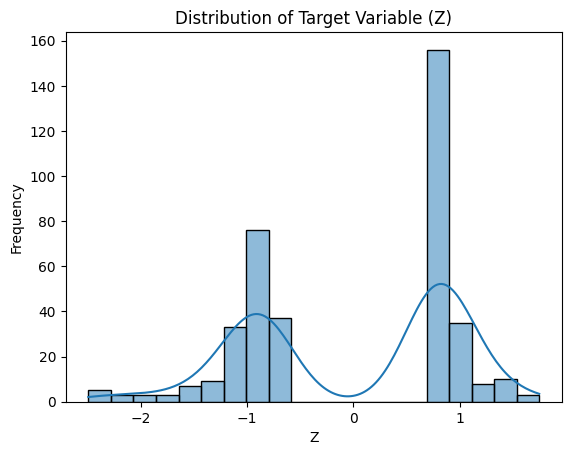

In [18]:
# plot the distribution of y
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(y.flatten(), bins=20, kde=True)
plt.title("Distribution of Target Variable (Z)")
plt.xlabel("Z")
plt.ylabel("Frequency")
plt.show()

In [5]:
from dataloader import preprocess

#X_train, y_train, X_test, y_test = preprocess(df=df, target="Z", testsize = 0.2)

# split X_train and y_train further into training and validation sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=42) # 0.25 x 0.8 = 0.2

In [6]:
# shape of the data
print("Training data shape:", X_train.shape, y_train.shape)
print("Validation data shape:", X_val.shape, y_val.shape)
print("Test data shape:", X_test.shape, y_test.shape)

Training data shape: (755, 101) (755,)
Validation data shape: (84, 101) (84,)
Test data shape: (210, 101) (210,)


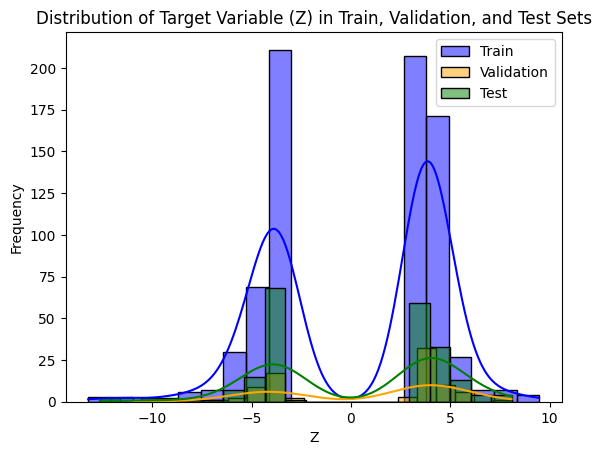

In [7]:
# plot distribution of test, val and train sets
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(y_train.flatten(), bins=20, kde=True, color="blue", label="Train")
sns.histplot(y_val.flatten(), bins=20, kde=True, color="orange", label="Validation")
sns.histplot(y_test.flatten(), bins=20, kde=True, color="green", label="Test")
plt.title("Distribution of Target Variable (Z) in Train, Validation, and Test Sets")
plt.xlabel("Z")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [8]:
# 

In [9]:
# normalize the features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()   
#X_train_scaled = scaler.fit_transform(X_train)
#X_test_scaled = scaler.transform(X_test)
#X_val_scaled = scaler.transform(X_val)

In [10]:
# scale the y values
y_scaler = StandardScaler()
y_train = y_scaler.fit_transform(y_train)
y_test = y_scaler.transform(y_test)
y_val = y_scaler.transform(y_val)

ValueError: Expected 2D array, got 1D array instead:
array=[ -3.81424482  -5.57544352   4.42966404  -3.37926467   3.73690401
  -5.94344114  -3.95311605   3.48496577   3.4502826   -3.38852353
   4.08393197  -5.74144869   3.45765435   3.59061392  -3.96079706
  -3.35237988   3.47745395  -3.33568342   4.09542205   4.57514072
  -3.31986806  -6.15383787   4.47503163  -5.58411     -4.01281081
   3.34703804  -4.84548933 -11.86518746   4.12187568   4.04555189
  -8.4321402   -3.34319393   3.6591026   -5.03050094  -4.05529999
  -3.30126479  -3.31109998  -3.44517016  -3.40871345   3.7052288
   3.96760017   4.12022658   3.47931357   3.45470267  -4.05939512
   3.80570647  -4.06506052   3.78647412   3.31025804  -3.57561915
  -3.39336333   3.94662666  -3.46572696   5.35282831   4.43778343
   3.62371642  -5.36448612   7.33196638  -4.97669235   3.62811328
   3.46961752  -3.54253555  -4.34464669 -12.42610594   5.96812193
   3.68322689   3.43958816   3.44936818   4.51097607   3.9352215
  -3.31574251   9.4

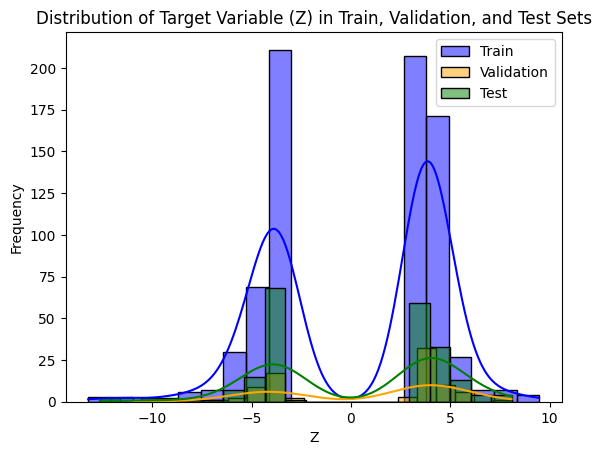

In [11]:
# plot distribution of test, val and train sets
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(y_train.flatten(), bins=20, kde=True, color="blue", label="Train")
sns.histplot(y_val.flatten(), bins=20, kde=True, color="orange", label="Validation")
sns.histplot(y_test.flatten(), bins=20, kde=True, color="green", label="Test")
plt.title("Distribution of Target Variable (Z) in Train, Validation, and Test Sets")
plt.xlabel("Z")
plt.ylabel("Frequency")
plt.legend()
plt.show()

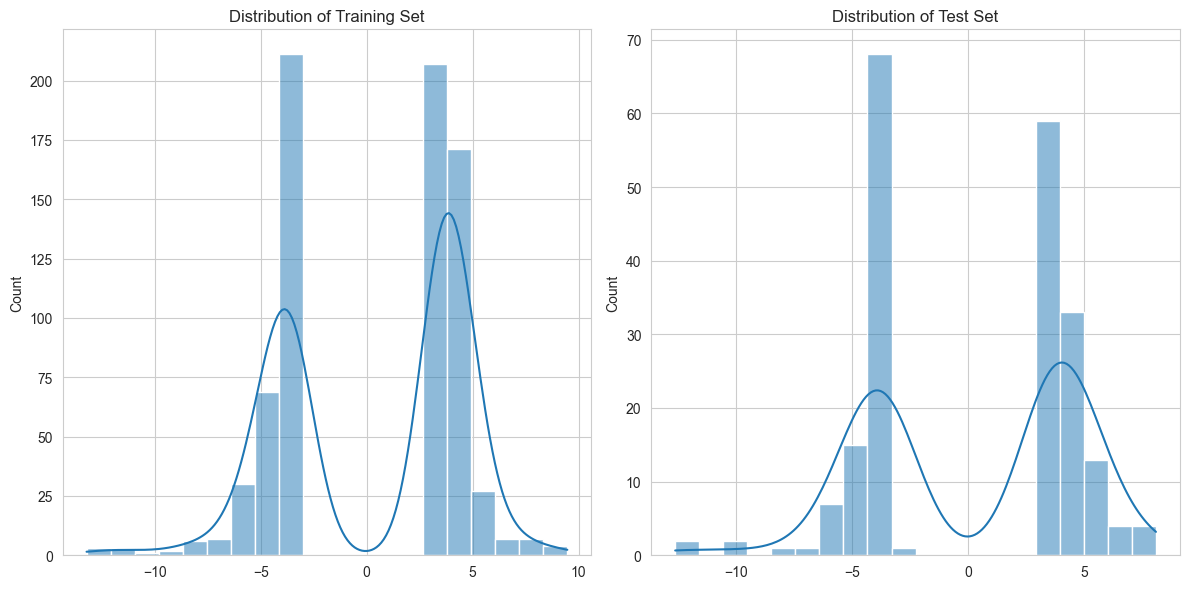

In [12]:
# plot distribution of train and test sets
import matplotlib.pyplot as plt
import seaborn as sns   
sns.set_style("whitegrid")
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.histplot(y_train, bins=20, kde=True)
plt.title("Distribution of Training Set")
plt.subplot(1, 2, 2)
sns.histplot(y_test, bins=20, kde=True)
plt.title("Distribution of Test Set")
plt.tight_layout()
plt.show()

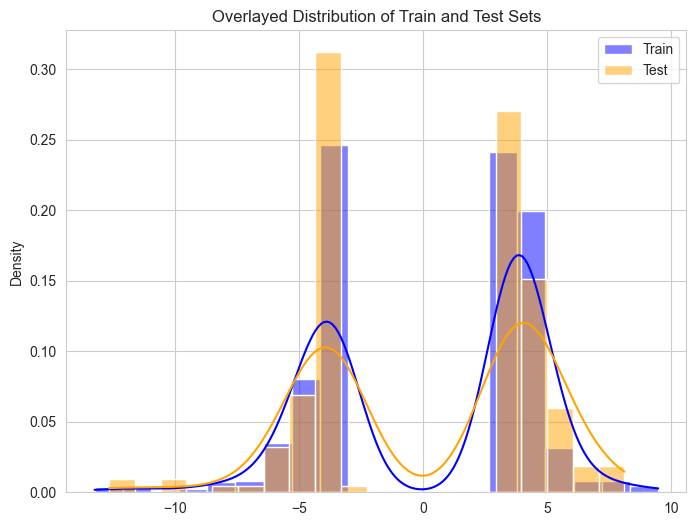

In [13]:
# plot overlayed relative distributions of train and test sets
plt.figure(figsize=(8, 6))
sns.histplot(y_train, bins=20, kde=True, color="blue", label="Train", stat="density", alpha=0.5)
sns.histplot(y_test, bins=20, kde=True, color="orange", label="Test", stat="density", alpha=0.5)
plt.title("Overlayed Distribution of Train and Test Sets")
plt.legend()
plt.show()

In [14]:
from torch.utils.data import DataLoader
from dataloader import GWASDataset

train_loader = DataLoader(GWASDataset(X_train, y_train), batch_size=64, shuffle=True)
val_loader = DataLoader(GWASDataset(X_val, y_val), batch_size=64, shuffle=False)
test_loader = DataLoader(GWASDataset(X_test, y_test), batch_size=64, shuffle=False)

In [23]:
from model import DNN, ResidualDNN

#model = DNN(input_dim=X_train.shape[1], hidden_dims=[50, 50, 50, 50, 50, 50], output_dim=1, dropout=0.2)
model = ResidualDNN(input_dim=X_train.shape[1], hidden_dims=[128,64,32], output_dim=1, dropout=0.2)

In [24]:
import torch
import torch.nn as nn

class DistributionAwareLoss(nn.Module):
    def __init__(self, alpha=1.0, beta=1.0):
        """
        Implementation of the Distribution-Aware Loss for Bimodal Regression.
        """
        super(DistributionAwareLoss, self).__init__()
        self.alpha = alpha
        self.beta = beta
        self.mse_criterion = nn.MSELoss()

    def normalize(self, D):
        """
        Non-linear normalization function from Eq. 6.
        Maps any raw distance D into the bounded interval [0, 1].
        """
        return 1.0 - (1.0 / (1.0 + D))

    def forward(self, y_pred, y_true):
        # Flatten tensors to 1D to ensure sorting and min/max operations 
        # work flawlessly regardless of batch dimension shapes (e.g., (B, 1) vs (B,))
        y_pred = y_pred.view(-1)
        y_true = y_true.view(-1)

        # ---------------------------------------------------------
        # Term 1: D_RMSE
        # ---------------------------------------------------------
        mse = self.mse_criterion(y_pred, y_true)
        # Add epsilon to prevent NaN gradients if MSE hits exactly 0
        d_rmse = torch.sqrt(mse + 1e-8) 

        # ---------------------------------------------------------
        # Term 2: D_Distribution (Wasserstein Distance)
        # ---------------------------------------------------------
        y_pred_sorted, _ = torch.sort(y_pred, dim=0)
        y_true_sorted, _ = torch.sort(y_true, dim=0)
        
        # 1D Wasserstein distance is the mean absolute difference of sorted values
        d_wasserstein = torch.mean(torch.abs(y_pred_sorted - y_true_sorted))

        # ---------------------------------------------------------
        # Term 3: D_Range (Range Alignment)
        # ---------------------------------------------------------
        pred_range = torch.max(y_pred) - torch.min(y_pred)
        true_range = torch.max(y_true) - torch.min(y_true)
        
        # Absolute difference between the predicted range and true range
        d_range = torch.abs(pred_range - true_range)

        # ---------------------------------------------------------
        # Final Combined Loss (Applying the N(D) normalization to all terms)
        # ---------------------------------------------------------
        loss_total = (
            self.normalize(d_rmse) + 
            (self.alpha * self.normalize(d_wasserstein)) + 
            (self.beta * self.normalize(d_range))
        )

        return loss_total

In [25]:
from torch import nn, optim
import torch

#criterion = nn.BCEWithLogitsLoss()


criterion = nn.MSELoss()
#criterion = DistributionAwareLoss(alpha=0.1, beta=0.1)
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

# learning rate scheduler
T_0 = 15
T_mult = 2
eta_min = 1e-6
#scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=T_0, T_mult=T_mult, eta_min=eta_min)
#scheduler = optim.lr_scheduler.CyclicLR(optimizer, base_lr=1e-7, max_lr=1e-5, step_size_up=10, mode='triangular2')

# scheduler StepLR
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=100, gamma=0.1)

train_losses = []
test_losses = []
learning_rates = []

val_higher = 0
l1_lambda = 0.01
 
for epoch in range(500):
    model.train()
    total_loss = 0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        predictions = model(batch_X)
        #print(f"Predictions shape: {predictions.shape}, Batch_y shape: {batch_y.shape}")
        mse_loss = criterion(predictions, batch_y)
        # print the shape of predictions and batch_y
        l1_penalty = sum(p.abs().sum() for name, p in model.named_parameters() if 'bias' not in name)
        loss = mse_loss + (l1_lambda * l1_penalty)
        
        
        # clip gradients to prevent exploding gradients
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * batch_X.size(0)
    scheduler.step()

    train_losses.append(total_loss / len(train_loader.dataset))
    learning_rates.append(optimizer.param_groups[0]['lr'])
    print(f"Epoch {epoch+1}, Loss: {total_loss / len(train_loader.dataset):.4f}")

    model.eval()
    test_loss = 0
    #criterion = nn.MSELoss()
 
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            predictions = model(batch_X)
            loss = criterion(predictions, batch_y)
            test_loss += loss.item() * batch_X.size(0)
    
    average_test_loss = test_loss / len(val_loader.dataset)
    test_losses.append(average_test_loss)
    print(f"Test Mean Squared Error: {average_test_loss:.4f}")

    # count number of epochs with higher validation loss than training loss
    if epoch > 0 and test_losses[-1] > test_losses[-2]:
        val_higher += 1
    else:        val_higher = 0

    if val_higher >= 20:
        print("Early stopping triggered due to 20 consecutive epochs with higher validation loss than training loss.")
        break

Epoch 1, Loss: 39.5934
Test Mean Squared Error: 18.7669
Epoch 2, Loss: 36.6202
Test Mean Squared Error: 17.6473
Epoch 3, Loss: 34.1275
Test Mean Squared Error: 17.4097
Epoch 4, Loss: 31.9259
Test Mean Squared Error: 16.9086
Epoch 5, Loss: 29.9526
Test Mean Squared Error: 16.5298
Epoch 6, Loss: 28.4048
Test Mean Squared Error: 16.2816
Epoch 7, Loss: 26.5721
Test Mean Squared Error: 15.6036
Epoch 8, Loss: 25.1252
Test Mean Squared Error: 15.2307
Epoch 9, Loss: 24.1444
Test Mean Squared Error: 15.1502
Epoch 10, Loss: 23.1623
Test Mean Squared Error: 14.4716
Epoch 11, Loss: 22.4900
Test Mean Squared Error: 15.8635
Epoch 12, Loss: 22.0479
Test Mean Squared Error: 15.2938
Epoch 13, Loss: 21.2720
Test Mean Squared Error: 15.1612
Epoch 14, Loss: 20.8431
Test Mean Squared Error: 14.6212
Epoch 15, Loss: 20.5104
Test Mean Squared Error: 15.3100
Epoch 16, Loss: 20.0399
Test Mean Squared Error: 14.3911
Epoch 17, Loss: 19.8031
Test Mean Squared Error: 14.7496
Epoch 18, Loss: 19.2052
Test Mean Square

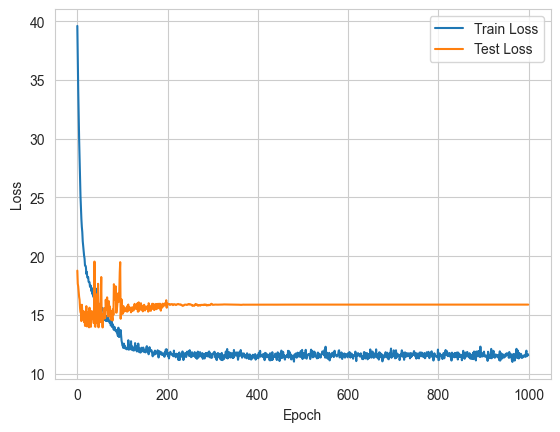

In [19]:
# plot training and test losses
import matplotlib.pyplot as plt
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [20]:
# get the r2 score of the dnn model on test test
preds = model(torch.tensor(X_test, dtype=torch.float32)).detach().numpy()
from sklearn.metrics import r2_score
r2 = r2_score(y_test, preds)
print(f"R2 score of DNN model on test set: {r2}")

R2 score of DNN model on test set: 0.01825128814708732


In [21]:
# print the squared correlation coefficient of the dnn model on test set
# with p value
from scipy import stats
corr_coef, p_value = stats.pearsonr(y_test.flatten(), preds.flatten())
print(f"Pearson Correlation Coefficient: {corr_coef**2:.4f}, p-value: {p_value:.4e}")

Pearson Correlation Coefficient: 0.0880, p-value: 1.2317e-05


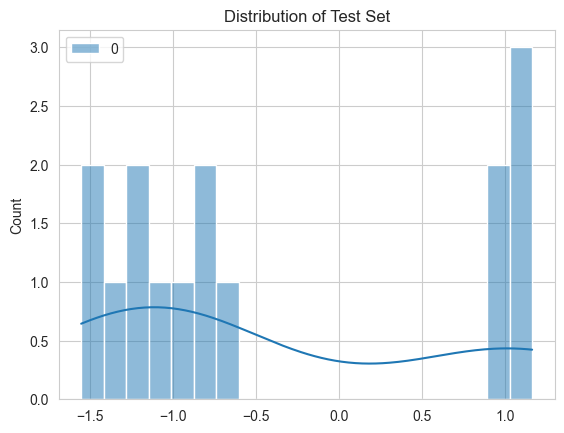

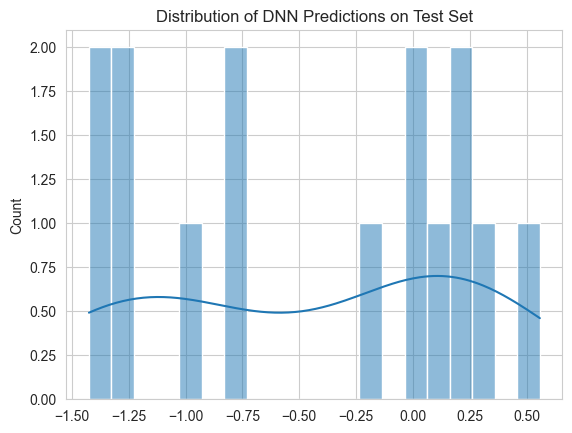

In [219]:
# plot distribution of y_test
import seaborn as sns
sns.histplot(y_test, bins=20, kde=True)
plt.title("Distribution of Test Set")
plt.show()

# plot distribution of predictions
sns.histplot(preds.flatten(), bins=20, kde=True)
plt.title("Distribution of DNN Predictions on Test Set")
plt.show()  

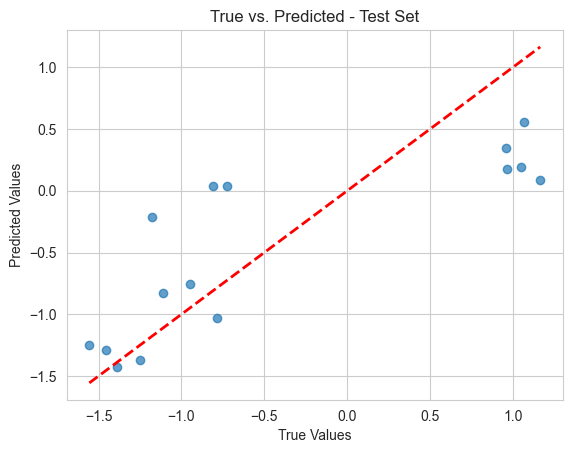

In [220]:
# plot true vs. predicted values for the test set
plt.scatter(y_test, preds, alpha=0.7)
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.title('True vs. Predicted - Test Set')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.show()

shape of residuals: (15, 1)
shape of preds: (15, 1)


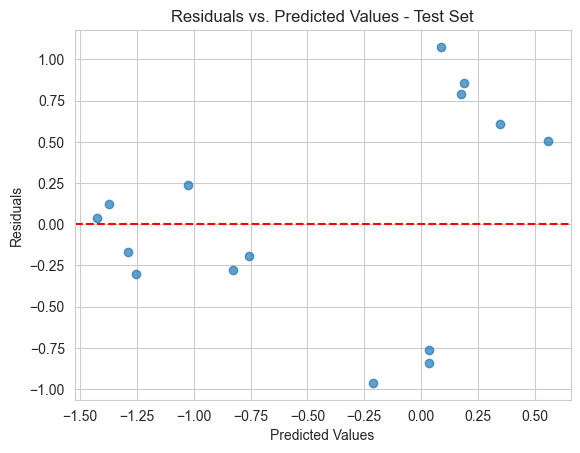

In [221]:
# make preds and y_test same dimension

preds = preds.flatten().reshape(-1, 1)
y_test = y_test.flatten().reshape(-1, 1)

# plot the residual distribution for the test set
residuals = y_test - preds

print("shape of residuals:", residuals.shape)
print("shape of preds:", preds.shape)
# plot residuals vs predicted values
plt.scatter(preds, residuals, alpha=0.7)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs. Predicted Values - Test Set')
plt.show()

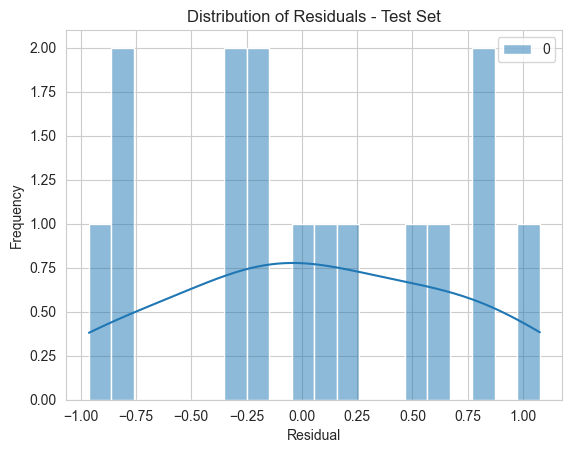

In [222]:
#. plot distribution of residuals
sns.histplot(residuals, bins=20, kde=True)
plt.title("Distribution of Residuals - Test Set")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()  

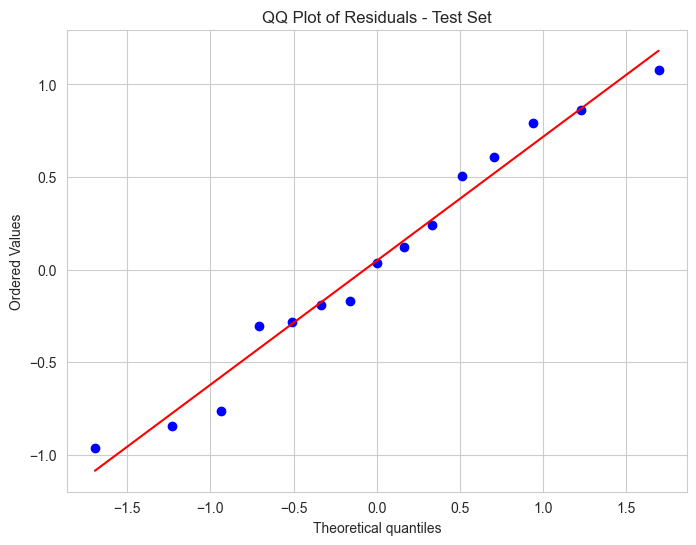

In [223]:
# create qq plot of residuals
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
plt.figure(figsize=(8, 6))
stats.probplot(residuals.flatten(), dist="norm", plot=plt)
plt.title("QQ Plot of Residuals - Test Set")
plt.show()

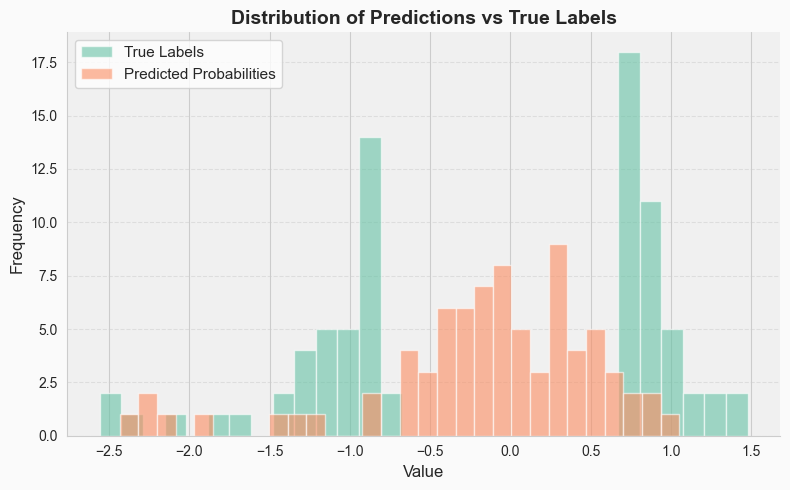

In [79]:
# just # Plot distribution of predictions vs true labels
fig, ax = plt.subplots(figsize=(8, 5))

ax.set_facecolor('#f0f0f0')
fig.patch.set_facecolor('#fafafa')

ax.hist(y_test, bins=30, alpha=0.6, label='True Labels', color='#66c2a5', edgecolor='white')
ax.hist(preds, bins=30, alpha=0.6, label='Predicted Probabilities', color='#fc8d62', edgecolor='white')

ax.set_xlabel('Value', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Distribution of Predictions vs True Labels', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

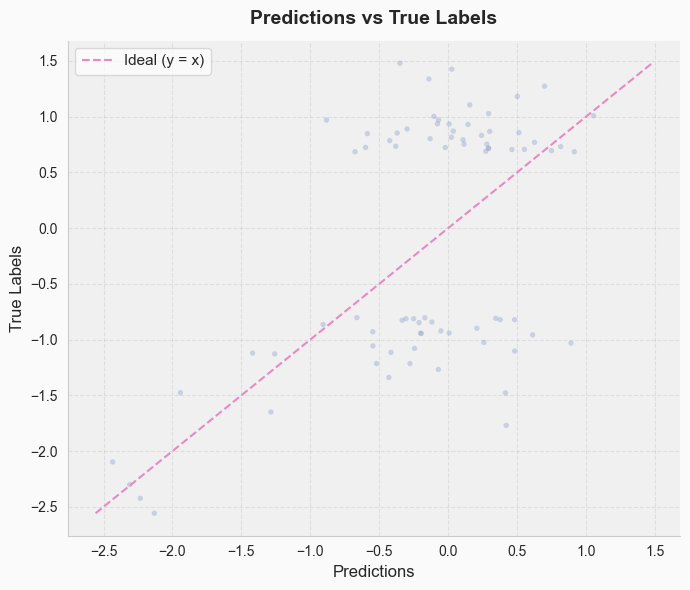

In [80]:
# plot predictions (x) vs true labels (y)
import numpy as np

fig, ax = plt.subplots(figsize=(7, 6))
ax.set_facecolor('#f0f0f0')
fig.patch.set_facecolor('#fafafa')

preds_flat = preds.flatten()
y_test_np = y_test.values if hasattr(y_test, 'values') else np.array(y_test)

ax.scatter(preds_flat, y_test_np, alpha=0.4, s=15, color='#8da0cb', edgecolors='none')

# identity line
lims = [min(preds_flat.min(), y_test_np.min()), max(preds_flat.max(), y_test_np.max())]
ax.plot(lims, lims, '--', color='#e78ac3', linewidth=1.5, label='Ideal (y = x)')

ax.set_xlabel('Predictions', fontsize=12)
ax.set_ylabel('True Labels', fontsize=12)
ax.set_title('Predictions vs True Labels', fontsize=14, fontweight='bold', pad=12)
ax.legend(fontsize=11, framealpha=0.7)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='both', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

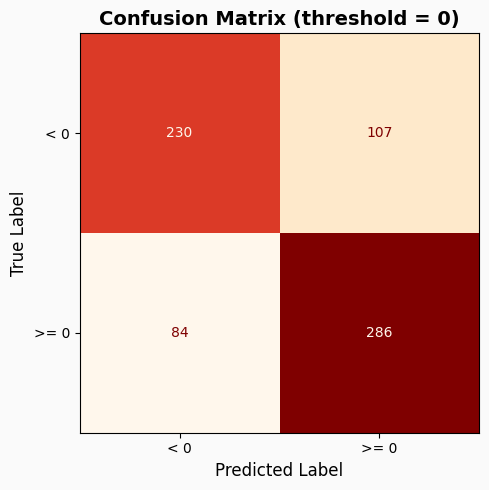

    Classification Metrics (thr = 1)
  Accuracy:    0.7298
  Precision:   0.7277
  Recall:      0.7730
  F1 Score:    0.7497

Classification Report:
              precision    recall  f1-score   support

         < 0       0.73      0.68      0.71       337
        >= 0       0.73      0.77      0.75       370

    accuracy                           0.73       707
   macro avg       0.73      0.73      0.73       707
weighted avg       0.73      0.73      0.73       707



In [55]:
# Binary classification at threshold = 1
import numpy as np
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

threshold = 0
y_true_bin = (y_test_np >= threshold).astype(int)
y_pred_bin = (preds_flat >= threshold).astype(int)

# Confusion matrix plot
cm = confusion_matrix(y_true_bin, y_pred_bin)
fig, ax = plt.subplots(figsize=(6, 5))
ax.set_facecolor('#f0f0f0')
fig.patch.set_facecolor('#fafafa')
disp = ConfusionMatrixDisplay(cm, display_labels=[f'< {threshold}', f'>= {threshold}'])
disp.plot(ax=ax, cmap='OrRd', values_format='d', colorbar=False)
ax.set_title(f'Confusion Matrix (threshold = {threshold})', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

# Classification metrics
accuracy = accuracy_score(y_true_bin, y_pred_bin)
precision = precision_score(y_true_bin, y_pred_bin, zero_division=0)
recall = recall_score(y_true_bin, y_pred_bin, zero_division=0)
f1 = f1_score(y_true_bin, y_pred_bin, zero_division=0)

print("=" * 40)
print("    Classification Metrics (thr = 1)")
print("=" * 40)
print(f"  Accuracy:    {accuracy:.4f}")
print(f"  Precision:   {precision:.4f}")
print(f"  Recall:      {recall:.4f}")
print(f"  F1 Score:    {f1:.4f}")
print("=" * 40)

print("\nClassification Report:")
print(classification_report(y_true_bin, y_pred_bin,
                            target_names=[f'< {threshold}', f'>= {threshold}'],
                            zero_division=0))